# DeepFashion Clothing Detector — YOLOv8 Fine-Tuning

Fine-tunes **YOLOv8n** on the DeepFashion In-Shop dataset using ground truth
bounding box annotations from `list_bbox_inshop.txt`.

---

### Why fine-tune YOLO on this specific dataset?

DeepFashion In-Shop images are clean studio shots with plain backgrounds.
Fine-tuning makes YOLO learn the exact visual characteristics of this dataset,
resulting in tighter and more accurate clothing crops compared to a general pretrained model.

---

### Cropping strategy
- **Offline pipeline** — ground truth bbox annotations used directly (perfect accuracy)
- **Online pipeline (Streamlit)** — fine-tuned YOLO used for user-uploaded images
  (annotations are not available for new images, so YOLO is required)

---

### Clothing categories
| Class ID | Label | clothes_type |
|----------|-------|-------------|
| 0 | upper_body | 1 (shirts, tops, jackets) |
| 1 | lower_body | 2 (trousers, skirts, shorts) |
| 2 | full_body  | 3 (dresses, jumpsuits) |

---

### Inputs
- `fashionimagesearchdataset` — raw images
- `fashionpreprocesseddataset` — master_df.csv with bbox annotations

### Outputs
- `best.pt` — fine-tuned YOLO weights (used in Streamlit online pipeline)
- Training metrics and visualisations

## 1. Install Libraries

In [1]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00


## 2. Imports and Device Check

In [2]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

warnings.filterwarnings('ignore')

COMPUTE_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Compute device : {COMPUTE_DEVICE}')
if COMPUTE_DEVICE == 'cuda':
    print(f'GPU name       : {torch.cuda.get_device_name(0)}')
print('Imports complete!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Compute device : cuda
GPU name       : Tesla T4
Imports complete!


## 3. Paths and Training Config

In [3]:
# ── Input datasets ────────────────────────────────────────────────────────────
RAW_IMG_ROOT  = '/kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img'
ANNOTATION_ROOT = '/kaggle/input/datasets/akibatra25/fashionpreprocesseddataset'

# ── Output ────────────────────────────────────────────────────────────────────
WORK_DIR    = '/kaggle/working'
DETECTOR_DIR = os.path.join(WORK_DIR, 'detector_dataset')
SAVED_CROPS  = os.path.join(WORK_DIR, 'data', 'yolo_crops')
os.makedirs(DETECTOR_DIR, exist_ok=True)
os.makedirs(SAVED_CROPS,  exist_ok=True)

# ── Training hyperparameters ──────────────────────────────────────────────────
N_EPOCHS     = 30
TRAIN_BATCH  = 16
INPUT_SIZE   = 416
STOP_PATIENCE = 7
STOP_DELTA    = 1e-4
CROP_PAD      = 10    # pixels of padding around each saved crop
DETECT_CONF   = 0.25  # minimum confidence for YOLO detection

# ── Category mapping ──────────────────────────────────────────────────────────
# clothes_type in annotations: 1=upper, 2=lower, 3=full
CATEGORY_NAMES = ['upper_body', 'lower_body', 'full_body']
N_CATEGORIES   = len(CATEGORY_NAMES)
TYPE_TO_CLS    = {1: 0, 2: 1, 3: 2}

# ── Verify paths ──────────────────────────────────────────────────────────────
for tag, p in [('RAW_IMG_ROOT', RAW_IMG_ROOT), ('ANNOTATION_ROOT', ANNOTATION_ROOT)]:
    status = 'Found ✓' if os.path.exists(p) else 'NOT FOUND ✗'
    print(f'[{status}] {tag}: {p}')

[Found ✓] RAW_IMG_ROOT: /kaggle/input/datasets/akibatra25/fashionimagesearchdataset/dataset/img
[Found ✓] ANNOTATION_ROOT: /kaggle/input/datasets/akibatra25/fashionpreprocesseddataset


## 4. Load Annotations CSV

`master_df.csv` was produced by the preprocessing notebook.
Contains image names, split labels, clothes_type, and ground truth bbox coordinates.

Only the **train split** is used for YOLO training.
Query and gallery images are used only at inference time.

In [4]:
annotation_df = pd.read_csv(os.path.join(ANNOTATION_ROOT, 'master_df.csv'))

print(f'Total rows  : {len(annotation_df):,}')
print(f'Columns     : {annotation_df.columns.tolist()}')
print()
print('Split counts:')
print(annotation_df['split'].value_counts().to_string())
print()
print('Clothing type counts (1=upper, 2=lower, 3=full):')
print(annotation_df['clothes_type'].value_counts().sort_index().to_string())

# Keep only train split for detector training
train_records = annotation_df[annotation_df['split'] == 'train'].reset_index(drop=True)
print(f'\nTrain records for YOLO fine-tuning: {len(train_records):,}')

Total rows  : 52,712
Columns     : ['image_name', 'item_id', 'split', 'clothes_type', 'pose_type', 'x1', 'y1', 'x2', 'y2']

Split counts:
split
train      25882
query      14218
gallery    12612

Clothing type counts (1=upper, 2=lower, 3=full):
clothes_type
1    33487
2    10494
3     8731

Train records for YOLO fine-tuning: 25,882


## 5. Train / Val Split for YOLO

Use 90% of train split for detector training and 10% for detector validation.
Stratified by clothing type to ensure all 3 classes are represented.

In [5]:
det_train, det_val = train_test_split(
    train_records,
    test_size=0.10,
    random_state=42,
    stratify=train_records['clothes_type']
)

det_train = det_train.reset_index(drop=True)
det_val   = det_val.reset_index(drop=True)

print(f'Detector train : {len(det_train):,} images')
print(f'Detector val   : {len(det_val):,} images')
print()
print('Train clothing type distribution:')
print(det_train['clothes_type'].value_counts().sort_index().to_string())
print()
print('Val clothing type distribution:')
print(det_val['clothes_type'].value_counts().sort_index().to_string())

Detector train : 23,293 images
Detector val   : 2,589 images

Train clothing type distribution:
clothes_type
1    15032
2     4405
3     3856

Val clothing type distribution:
clothes_type
1    1671
2     490
3     428


## 6. Helper Functions

In [6]:
def full_image_path(img_name):
    """Resolve annotation image_name to full path on disk."""
    rel = img_name[4:] if img_name.startswith('img/') else img_name
    return os.path.join(RAW_IMG_ROOT, rel)


def abs_to_yolo(x1, y1, x2, y2, img_w, img_h):
    """
    Convert absolute bbox (x1,y1,x2,y2) → YOLO format (cx, cy, w, h)
    All values normalised to [0, 1].
    """
    cx = ((x1 + x2) / 2.0) / img_w
    cy = ((y1 + y2) / 2.0) / img_h
    bw = (x2 - x1) / img_w
    bh = (y2 - y1) / img_h
    # Clamp all values to valid range
    cx = float(min(max(cx, 0.0), 1.0))
    cy = float(min(max(cy, 0.0), 1.0))
    bw = float(min(max(bw, 0.0), 1.0))
    bh = float(min(max(bh, 0.0), 1.0))
    return cx, cy, bw, bh


# Quick test
sample      = det_train.iloc[0]
sample_path = full_image_path(sample['image_name'])
sample_img  = Image.open(sample_path)
W, H        = sample_img.size
cx, cy, bw, bh = abs_to_yolo(sample['x1'], sample['y1'], sample['x2'], sample['y2'], W, H)
print(f'Sample image size : {W}x{H}')
print(f'GT bbox           : ({sample["x1"]}, {sample["y1"]}, {sample["x2"]}, {sample["y2"]})')
print(f'YOLO format       : cx={cx:.4f} cy={cy:.4f} w={bw:.4f} h={bh:.4f}')
print(f'Category ID       : {TYPE_TO_CLS[sample["clothes_type"]]} ({CATEGORY_NAMES[TYPE_TO_CLS[sample["clothes_type"]]]})')

Sample image size : 256x256
GT bbox           : (108, 48, 154, 217)
YOLO format       : cx=0.5117 cy=0.5176 w=0.1797 h=0.6602
Category ID       : 0 (upper_body)


## 7. Build YOLO Dataset on Disk

Required folder structure:
```
detector_dataset/
    train/
        images/   ← jpg files
        labels/   ← txt files
    val/
        images/
        labels/
    data.yaml
```
Each label file: `class_id  cx  cy  w  h` (one line per object, normalised)

Expected time: **3-5 minutes**

In [7]:
def prepare_detector_split(records_df, partition):
    img_out   = os.path.join(DETECTOR_DIR, partition, 'images')
    label_out = os.path.join(DETECTOR_DIR, partition, 'labels')
    os.makedirs(img_out,   exist_ok=True)
    os.makedirs(label_out, exist_ok=True)

    n_ok = 0
    n_skip = 0

    for idx, row in tqdm(records_df.iterrows(), total=len(records_df), desc=partition):
        src = full_image_path(row['image_name'])
        if not os.path.exists(src):
            n_skip += 1
            continue

        stem      = f'{partition}_{idx:06d}'
        dst_img   = os.path.join(img_out,   f'{stem}.jpg')
        dst_label = os.path.join(label_out, f'{stem}.txt')

        if os.path.exists(dst_img) and os.path.exists(dst_label):
            n_ok += 1
            continue

        # Symlink image to save disk space
        if not os.path.exists(dst_img):
            try:
                os.symlink(os.path.abspath(src), dst_img)
            except Exception:
                shutil.copy2(src, dst_img)

        # Load image to get dimensions
        try:
            pil = Image.open(src)
            W, H = pil.size
        except Exception:
            n_skip += 1
            continue

        # Write YOLO label
        cls_id          = TYPE_TO_CLS.get(int(row['clothes_type']), 0)
        cx, cy, bw, bh  = abs_to_yolo(row['x1'], row['y1'], row['x2'], row['y2'], W, H)

        if bw <= 0 or bh <= 0:
            n_skip += 1
            continue

        with open(dst_label, 'w') as lf:
            lf.write(f'{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')

        n_ok += 1

    print(f'  {partition}: prepared={n_ok:,}  skipped={n_skip:,}')
    return n_ok


print('Preparing YOLO dataset...')
n_det_train = prepare_detector_split(det_train, 'train')
n_det_val   = prepare_detector_split(det_val,   'val')
print(f'\nDataset ready — train: {n_det_train:,}  val: {n_det_val:,}')

Preparing YOLO dataset...


train: 100%|██████████| 23293/23293 [01:48<00:00, 214.57it/s]


  train: prepared=23,293  skipped=0


val: 100%|██████████| 2589/2589 [00:11<00:00, 228.93it/s]

  val: prepared=2,589  skipped=0

Dataset ready — train: 23,293  val: 2,589


## 8. Write data.yaml

In [8]:
yaml_file = os.path.join(DETECTOR_DIR, 'data.yaml')

yaml_text = (
    f'path: {DETECTOR_DIR}\n'
    f'train: train/images\n'
    f'val:   val/images\n'
    f'\n'
    f'nc: {N_CATEGORIES}\n'
    f'names: {CATEGORY_NAMES}\n'
)

with open(yaml_file, 'w') as fh:
    fh.write(yaml_text)

print('data.yaml written:')
print(yaml_text)

data.yaml written:
path: /kaggle/working/detector_dataset
train: train/images
val:   val/images

nc: 3
names: ['upper_body', 'lower_body', 'full_body']



## 9. Visualise Labels Before Training

Draw annotation boxes on sample images to confirm labels are correct.

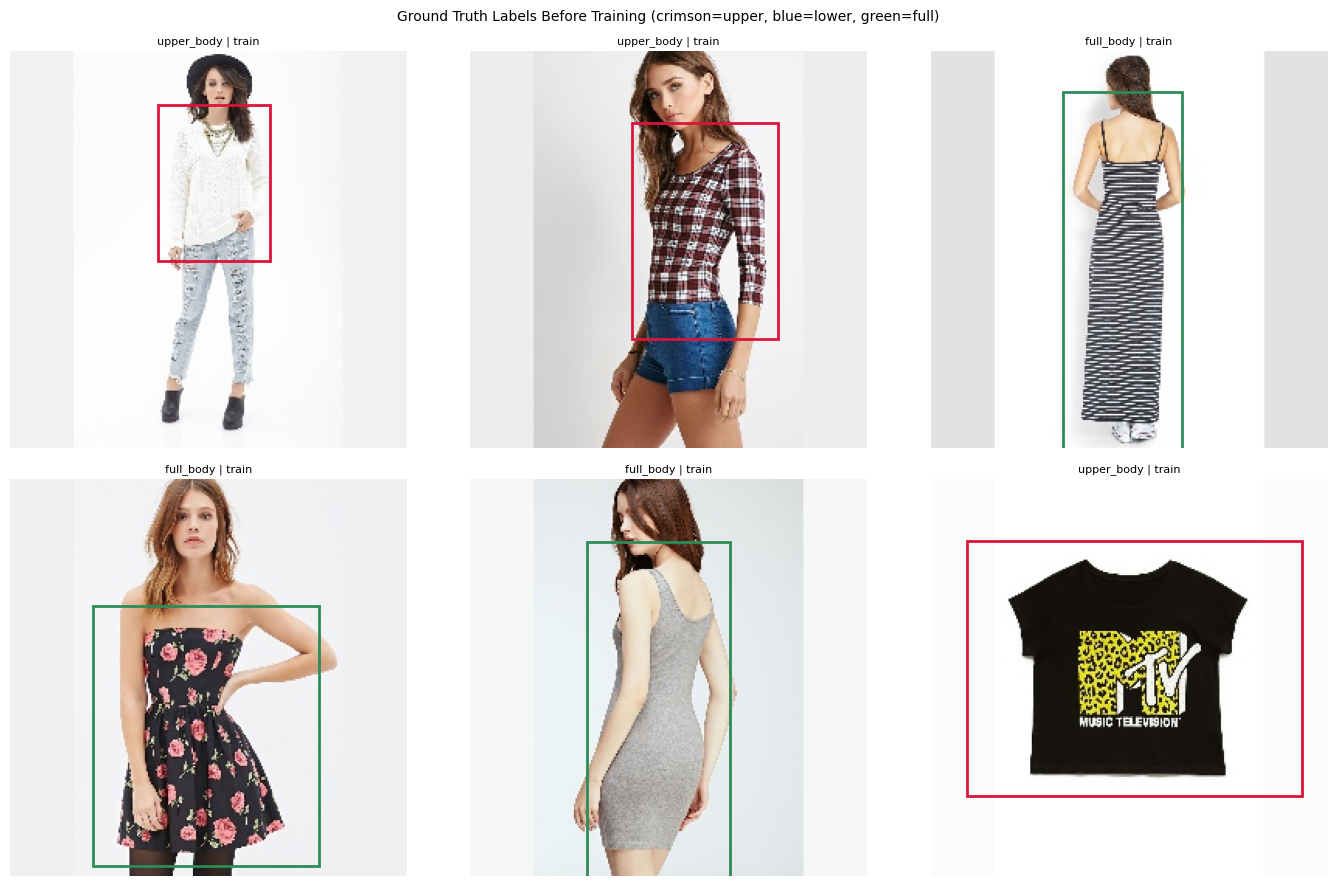

In [9]:
CAT_COLORS = ['crimson', 'steelblue', 'seagreen']
viz_rows   = det_train.sample(6, random_state=7)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (_, row) in enumerate(viz_rows.iterrows()):
    img_path = full_image_path(row['image_name'])
    if not os.path.exists(img_path):
        axes[i].axis('off')
        continue

    pil  = Image.open(img_path).convert('RGB')
    W, H = pil.size
    cls  = TYPE_TO_CLS.get(int(row['clothes_type']), 0)
    cx, cy, bw, bh = abs_to_yolo(row['x1'], row['y1'], row['x2'], row['y2'], W, H)

    # Back to pixel coords for drawing
    px1 = (cx - bw / 2) * W
    py1 = (cy - bh / 2) * H

    rect = patches.Rectangle(
        (px1, py1), bw * W, bh * H,
        linewidth=2, edgecolor=CAT_COLORS[cls], facecolor='none'
    )
    axes[i].imshow(pil)
    axes[i].add_patch(rect)
    axes[i].set_title(f'{CATEGORY_NAMES[cls]} | {row["split"]}', fontsize=8)
    axes[i].axis('off')

plt.suptitle(
    'Ground Truth Labels Before Training (crimson=upper, blue=lower, green=full)',
    fontsize=10
)
plt.tight_layout()
plt.show()

## 10. Fine-Tune YOLOv8n

Fine-tunes the nano detection model on our clothing dataset.
Freezes the backbone (first 10 layers) and trains the detection head only — faster and avoids overfitting on simple studio images.

Expected time: **60-90 minutes** on T4 GPU.

In [10]:
class EarlyStop:
    """Stops training when validation fitness stops improving."""
    def __init__(self, patience=STOP_PATIENCE, min_delta=STOP_DELTA):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = None
        self.counter   = 0
        self.triggered = False

    def step(self, score):
        if self.best is None:
            self.best = score
        elif score < self.best + self.min_delta:
            self.counter += 1
            print(f'  [EarlyStop] No improvement {self.counter}/{self.patience} '
                  f'(best={self.best:.4f} current={score:.4f})')
            if self.counter >= self.patience:
                print('  [EarlyStop] Triggered — stopping.')
                self.triggered = True
        else:
            print(f'  [EarlyStop] Improved {self.best:.4f} → {score:.4f}')
            self.best    = score
            self.counter = 0


stopper = EarlyStop()


def epoch_end_hook(trainer):
    ep   = trainer.epoch + 1
    loss = trainer.loss.item() if hasattr(trainer.loss, 'item') else float(trainer.loss)
    print(f'Epoch {ep}/{N_EPOCHS} — loss: {loss:.4f}')
    fit = trainer.metrics.get('fitness', None)
    stopper.step(fit if fit is not None else -loss)
    if stopper.triggered:
        trainer.epoch = trainer.epochs


detector = YOLO('yolov8n.pt')
detector.add_callback('on_train_epoch_end', epoch_end_hook)

print(f'Fine-tuning YOLOv8n for up to {N_EPOCHS} epochs...')
print(f'Detector train : {n_det_train:,}  val : {n_det_val:,}')
print(f'Categories     : {CATEGORY_NAMES}')
print()

detector.train(
    data    = yaml_file,
    epochs  = N_EPOCHS,
    batch   = TRAIN_BATCH,
    imgsz   = INPUT_SIZE,
    device  = COMPUTE_DEVICE,
    freeze  = 10,
    patience= STOP_PATIENCE,
    project = WORK_DIR,
    name    = 'detector_run',
    verbose = False,
)

best_detector = YOLO(detector.trainer.best)
print(f'\nBest weights at: {detector.trainer.best}')

Fine-tuning YOLOv8n for up to 30 epochs...
Detector train : 23,293  val : 2,589
Categories     : ['upper_body', 'lower_body', 'full_body']

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/detector_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mome

## 11. Evaluate Fine-Tuned Detector

In [11]:
eval_results = best_detector.val(data=yaml_file, verbose=False)
det_box = eval_results.box

print('=' * 50)
print('DETECTOR EVALUATION RESULTS')
print('=' * 50)
print(f'mAP@[0.5:0.95] : {float(det_box.map):.4f}')
print(f'mAP@0.50       : {float(det_box.map50):.4f}')
print(f'mAP@0.75       : {float(det_box.map75):.4f}')
print()
print('Per-class mAP@0.50:')
for i, name in enumerate(CATEGORY_NAMES):
    print(f'  {name:<15}: {float(det_box.maps[i]):.4f}')

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 19.2±11.1 MB/s, size: 15.3 KB)
val: Scanning /kaggle/working/detector_dataset/val/labels.cache... 2589 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2589/2589 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 162/162 12.3it/s 13.2s
                   all       2589       2589       0.88       0.89      0.934      0.743
Speed: 0.4ms preprocess, 1.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
DETECTOR EVALUATION RESULTS
mAP@[0.5:0.95] : 0.7429
mAP@0.50       : 0.9338
mAP@0.75       : 0.8455

Per-class mAP@0.50:
  upper_body     : 0.7502
  lower_body     : 0.7235
  full_body      : 0.7550


## 12. Copy best.pt to Output Root

In [12]:
weights_src = detector.trainer.best
weights_dst = os.path.join(WORK_DIR, 'best.pt')
shutil.copy2(weights_src, weights_dst)

print(f'best.pt copied to : {weights_dst}')
print(f'File size         : {os.path.getsize(weights_dst)/1e6:.1f} MB')

best.pt copied to : /kaggle/working/best.pt
File size         : 6.2 MB


## 13. Visualise Detections on Sample Images

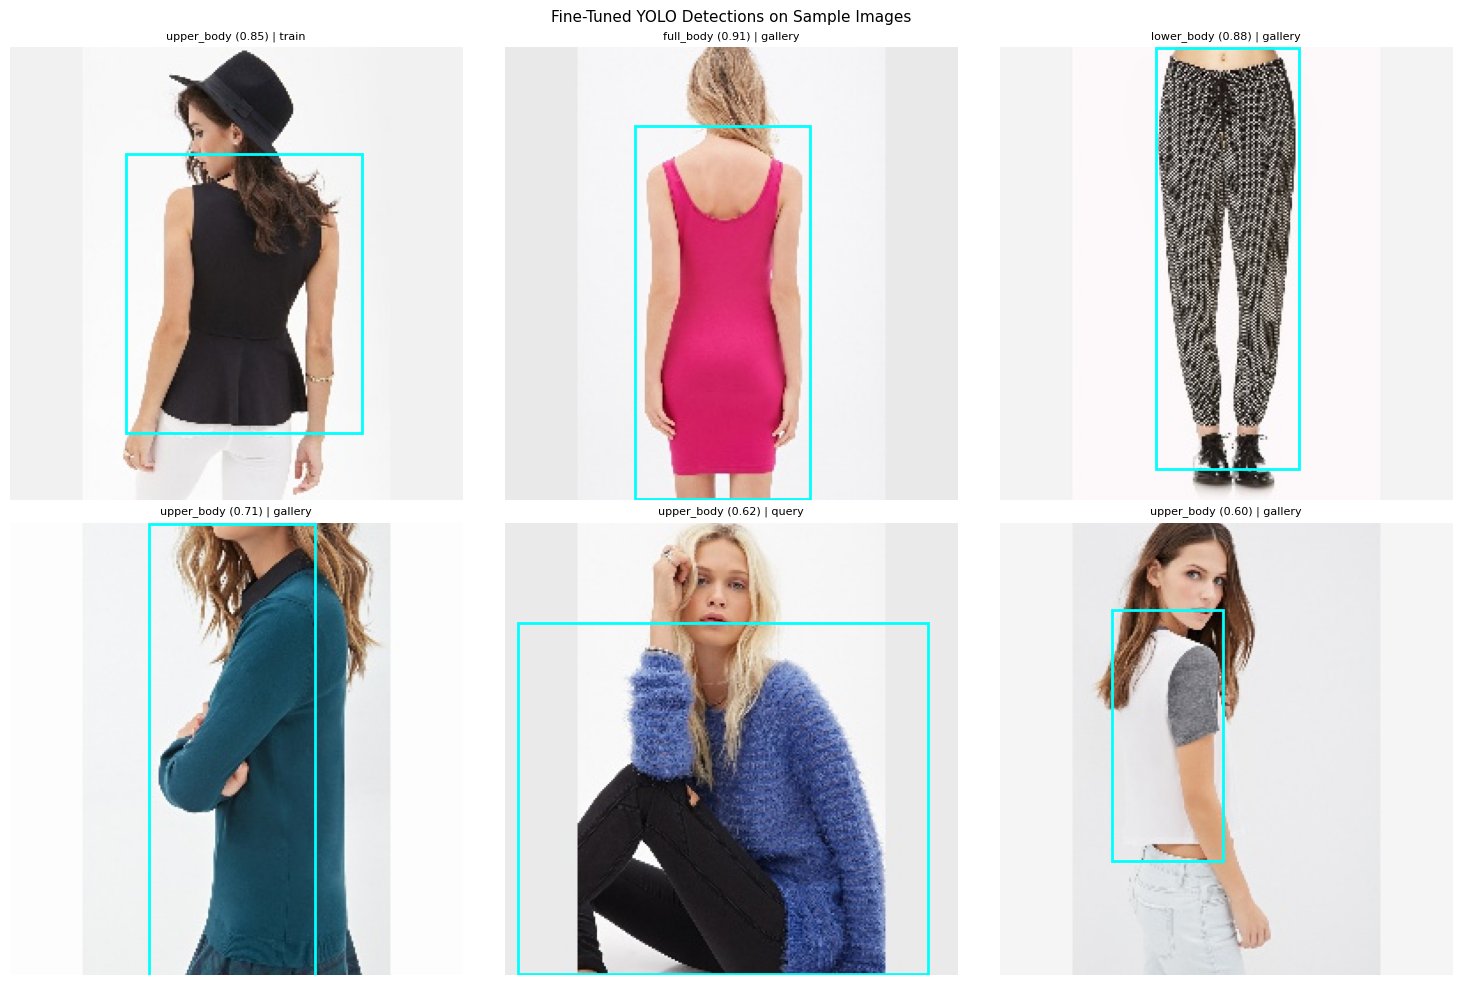

In [13]:
viz_sample = annotation_df.sample(6, random_state=55)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(viz_sample.iterrows()):
    img_path = full_image_path(row['image_name'])
    if not os.path.exists(img_path):
        axes[i].axis('off')
        continue

    pil     = Image.open(img_path).convert('RGB')
    preds   = best_detector(img_path, conf=DETECT_CONF, verbose=False)

    axes[i].imshow(pil)

    if preds and len(preds[0].boxes) > 0:
        boxes    = preds[0].boxes
        top_idx  = boxes.conf.argmax().item()
        x1, y1, x2, y2 = boxes.xyxy[top_idx].cpu().numpy().astype(int)
        cls_id   = int(boxes.cls[top_idx].item())
        conf_val = float(boxes.conf[top_idx].item())
        cat_name = CATEGORY_NAMES[cls_id] if cls_id < len(CATEGORY_NAMES) else str(cls_id)

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='cyan', facecolor='none'
        )
        axes[i].add_patch(rect)
        axes[i].set_title(f'{cat_name} ({conf_val:.2f}) | {row["split"]}', fontsize=8)
    else:
        axes[i].set_title(f'No detection | {row["split"]}', fontsize=8)

    axes[i].axis('off')

plt.suptitle('Fine-Tuned YOLO Detections on Sample Images', fontsize=11)
plt.tight_layout()
plt.show()

## 14. Crop All 52k Images with Fine-Tuned YOLO

Runs the fine-tuned detector on every image (train + query + gallery).
Fallback to ground truth bbox if YOLO finds nothing.

Expected time: **25-40 minutes** on T4 GPU.

In [14]:
def crop_save_path(img_name):
    rel = img_name[4:] if img_name.startswith('img/') else img_name
    return os.path.join(SAVED_CROPS, rel)


def save_region(pil_img, x1, y1, x2, y2, dest, pad=CROP_PAD):
    W, H = pil_img.size
    l = max(0, int(x1) - pad)
    t = max(0, int(y1) - pad)
    r = min(W, int(x2) + pad)
    b = min(H, int(y2) + pad)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    pil_img.crop((l, t, r, b)).save(dest, quality=95)


saved_crop_paths = []
detector_used    = []
detected_cats    = []
failed_list      = []
n_yolo_crops     = 0
n_fallback_crops = 0

for _, entry in tqdm(annotation_df.iterrows(), total=len(annotation_df), desc='Cropping'):
    src  = full_image_path(entry['image_name'])
    dest = crop_save_path(entry['image_name'])
    saved_crop_paths.append(dest)

    if os.path.exists(dest):
        detector_used.append(None)
        detected_cats.append(None)
        continue

    if not os.path.exists(src):
        failed_list.append(entry['image_name'])
        detector_used.append(False)
        detected_cats.append(None)
        continue

    try:
        pil   = Image.open(src).convert('RGB')
        preds = best_detector(src, conf=DETECT_CONF, verbose=False)

        if preds and len(preds[0].boxes) > 0:
            bxs     = preds[0].boxes
            top_i   = bxs.conf.argmax().item()
            x1, y1, x2, y2 = bxs.xyxy[top_i].cpu().numpy().astype(int)
            cat_id  = int(bxs.cls[top_i].item())
            cat_nm  = CATEGORY_NAMES[cat_id] if cat_id < len(CATEGORY_NAMES) else str(cat_id)
            save_region(pil, x1, y1, x2, y2, dest)
            detector_used.append(True)
            detected_cats.append(cat_nm)
            n_yolo_crops += 1
        else:
            # Fallback: use ground truth bbox
            save_region(pil, entry['x1'], entry['y1'], entry['x2'], entry['y2'], dest)
            detector_used.append(False)
            detected_cats.append('fallback')
            n_fallback_crops += 1

    except Exception as err:
        failed_list.append(entry['image_name'])
        detector_used.append(False)
        detected_cats.append(None)

print(f'YOLO crops    : {n_yolo_crops:,}')
print(f'Fallback crops: {n_fallback_crops:,}')
print(f'Failed        : {len(failed_list):,}')

Cropping: 100%|██████████| 52712/52712 [14:09<00:00, 62.04it/s]

YOLO crops    : 52,472
Fallback crops: 240
Failed        : 0


## 15. Save Output CSVs

In [15]:
# Pad lists if needed
while len(detector_used) < len(annotation_df):
    detector_used.append(None)
while len(detected_cats) < len(annotation_df):
    detected_cats.append(None)

annotation_df['crop_path']      = saved_crop_paths
annotation_df['yolo_used']      = detector_used[:len(annotation_df)]
annotation_df['detected_class'] = detected_cats[:len(annotation_df)]
annotation_df['crop_exists']    = annotation_df['crop_path'].apply(os.path.exists)

annotation_df.to_csv(os.path.join(WORK_DIR, 'master_crops.csv'), index=False)

for partition in ['train', 'query', 'gallery']:
    part_df = annotation_df[annotation_df['split'] == partition].reset_index(drop=True)
    part_df.to_csv(os.path.join(WORK_DIR, f'{partition}_crops.csv'), index=False)
    n_found = part_df['crop_exists'].sum()
    print(f'{partition}_crops.csv : {len(part_df):,} rows  crops on disk: {n_found:,}')

print(f'\nmaster_crops.csv  : {len(annotation_df):,} rows')
print(f'Total crops       : {annotation_df["crop_exists"].sum():,} / {len(annotation_df):,}')

train_crops.csv : 25,882 rows  crops on disk: 25,882
query_crops.csv : 14,218 rows  crops on disk: 14,218
gallery_crops.csv : 12,612 rows  crops on disk: 12,612

master_crops.csv  : 52,712 rows
Total crops       : 52,712 / 52,712


## 16. Final Summary

In [16]:
print('=' * 57)
print('   YOLO FINE-TUNING + CROPPING COMPLETE')
print('=' * 57)
print(f'  Model          : YOLOv8n fine-tuned on DeepFashion')
print(f'  Epochs         : {N_EPOCHS}')
print(f'  Categories     : {CATEGORY_NAMES}')
print(f'  mAP@0.50       : {float(det_box.map50):.4f}')
print()
print(f'  Total images   : {len(annotation_df):,}')
print(f'  YOLO crops     : {n_yolo_crops:,}')
print(f'  Fallback crops : {n_fallback_crops:,}')
print(f'  Failed         : {len(failed_list):,}')
print()
print('  Save as Kaggle dataset:')
print('    best.pt            ← fine-tuned YOLO (for Streamlit online pipeline)')
print('    master_crops.csv')
print('    train_crops.csv')
print('    query_crops.csv')
print('    gallery_crops.csv')
print('    data/yolo_crops/   ← all cropped images')
print()
print('  Next notebook: BLIP-2 Captioning')
print('=' * 57)

   YOLO FINE-TUNING + CROPPING COMPLETE
  Model          : YOLOv8n fine-tuned on DeepFashion
  Epochs         : 30
  Categories     : ['upper_body', 'lower_body', 'full_body']
  mAP@0.50       : 0.9338

  Total images   : 52,712
  YOLO crops     : 52,472
  Fallback crops : 240
  Failed         : 0

  Save as Kaggle dataset:
    best.pt            ← fine-tuned YOLO (for Streamlit online pipeline)
    master_crops.csv
    train_crops.csv
    query_crops.csv
    gallery_crops.csv
    data/yolo_crops/   ← all cropped images

  Next notebook: BLIP-2 Captioning
